# Giai đoạn 1: Tiền xử lý & Làm sạch dữ liệu

Notebook này triển khai toàn bộ quy trình tiền xử lý và làm sạch dữ liệu cho dự án **Phân cụm thị trường việc làm Việt Nam**.

### Mục tiêu chính:
1. **Tải dữ liệu thô** từ Hugging Face hoặc đọc trực tiếp từ bộ đệm cục bộ (local cache) nếu tệp đã tồn tại.
2. **Phân tích cấu trúc dữ liệu thô** và thực hiện **loại bỏ các thuộc tính không cần thiết** (như mã định danh kỹ thuật, tên công ty gây nhiễu, năm tuyển dụng).
3. **Chia dữ liệu** thành 2 tập Train (90%) và Test (10%).
4. **Làm sạch văn bản tiếng Việt cơ bản** (xóa HTML, URL, email, số điện thoại, ký tự đặc biệt, chuẩn hóa khoảng trắng).
5. **Trích xuất thông tin lương và kinh nghiệm** thành các cột số thực tế (Triệu VND/tháng và Số năm kinh nghiệm).
6. **Xử lý giá trị trống (Imputation)** bằng Yếu vị (Mode) cho dữ liệu phân loại và Trung vị (Median) cho dữ liệu số.
7. **Xử lý giá trị ngoại lệ (Outliers)**: Lọc các tin tuyển dụng quá ngắn hoặc quá dài; sử dụng winsorize percentile trên tập Train để giới hạn nhẹ các mức lương cực trị, tránh làm méo cụm.
8. **Trực quan hóa sự khác biệt** của dữ liệu trước và sau khi xử lý.

In [49]:
# Khai báo các thư viện phục vụ phân tích dữ liệu và trực quan hóa
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from IPython.display import display

# Thiết lập giao diện vẽ đồ thị đẹp mắt
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Đọc mã token xác thực Hugging Face từ tệp .env (nếu có) để tăng giới hạn tải API
if os.path.exists('.env') or os.path.exists('../.env'):
    env_path = '.env' if os.path.exists('.env') else '../.env'
    with open(env_path) as f:
        for line in f:
            if line.strip() and not line.startswith('#'):
                parts = line.strip().split('=', 1)
                if len(parts) == 2:
                    os.environ[parts[0]] = parts[1]
    print("Đã tải HF_TOKEN thành công từ tệp cấu hình bảo mật .env.")

Đã tải HF_TOKEN thành công từ tệp cấu hình bảo mật .env.


## 1. Tải và Khảo sát Bộ dữ liệu Thô

Hệ thống sẽ kiểm tra xem dữ liệu thô cục bộ đã tồn tại chưa để ưu tiên đọc trực tiếp từ đĩa giúp tăng tốc độ chạy. Nếu chưa có, chương trình sẽ tự động tải từ kho dữ liệu Hugging Face `tinixai/vietnamese-job-descriptions` và dùng hàm tối ưu `ds.to_pandas()` để chuyển đổi nhanh sang dạng bảng DataFrame.

In [50]:
raw_train_path = "../data/raw_data_train.csv"
raw_test_path = "../data/raw_data_test.csv"
os.makedirs("../data", exist_ok=True)

if os.path.exists(raw_train_path) and os.path.exists(raw_test_path):
    print("Tìm thấy dữ liệu thô lưu cục bộ. Đang tiến hành đọc nhanh từ đĩa...")
    df_raw_train = pd.read_csv(raw_train_path)
    df_raw_test = pd.read_csv(raw_test_path)
    skip_split = True
    print(f"Tải thành công. Kích thước Train thô: {df_raw_train.shape} | Test thô: {df_raw_test.shape}")
    print("\n--- XEM TRƯỚC 10 DÒNG DỮ LIỆU THÔ BAN ĐẦU (TẬP TRAIN) ---")
    display(df_raw_train.head(10))
else:
    print("Không tìm thấy file cục bộ. Đang tải dataset từ Hugging Face...")
    ds = load_dataset('tinixai/vietnamese-job-descriptions', split='train')
    df_raw = ds.to_pandas()
    skip_split = False
    print(f"Tải thành công từ Hugging Face. Kích thước tập dữ liệu thô: {df_raw.shape}") # type: ignore
    print("\n--- XEM TRƯỚC 10 DÒNG DỮ LIỆU THÔ BAN ĐẦU VỪA TẢI ---")
    display(df_raw.head(10)) # type: ignore

Tìm thấy dữ liệu thô lưu cục bộ. Đang tiến hành đọc nhanh từ đĩa...
Tải thành công. Kích thước Train thô: (546190, 14) | Test thô: (60688, 14)

--- XEM TRƯỚC 10 DÒNG DỮ LIỆU THÔ BAN ĐẦU (TẬP TRAIN) ---


,id,job_title,company_name,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,year
0,301834,Nhân Viên Kinh Doanh - Thu Nhập Đến 30 Triệu (...,Công Ty TNHH Bê Tông Trang Trí Việt Nam,12.000.000 - 30.000.000 VND,"Tầng 5, Tòa nhà Phú Hưng 298 Ung Văn Khiêm | 5...",Toàn thời gian,Xây dựng,6 năm,Cao đẳng,Nhân viên,"Lên kế hoạch tiếp cận, chăm sóc khách hàng là ...",Thu nhập: Từ 12- 30 triệu ( Lương cứng + hoa h...,"Độ tuổi từ 27-40, tốt nghiệp cao đẳng, đại học...",2024
1,477331,NV Pha Chế. Caffe,Caffe,6.000.000 - 10.000.000 VND,880 tỉnh lộ 43 phường bình chiểu,Remote,Bán hàng - Kinh doanh,2 năm,Không,Nhân viên,"Tìm kiếm khách hàng tiềm năng, mở rộng nguồn k...",Lương cơ bản + hoa hồng + thưởng KPI - Được hư...,"Nam/Nữ Từ 22 – 35 tuổi, có đam mê và nhiệt huy...",2025
2,540064,Kỹ Sư Giám Sát Xây Dựng,Công Ty TNHH XD TM DV Không Gian Đẹp,10.000.000 - 15.000.000 VND,"68 Song Hành, Quốc lộ 22, Trung Chánh | 72/3C ...",Toàn thời gian,Xây dựng,5 năm,Đại học,Nhân viên,"• Giám sát, Quản lý các tổ đội, từ phần thô đế...",• Mức lương: 10 - 14tr + Phụ cấp công việc • P...,• Tốt nghiệp Đại học chuyên ngành Xây dựng Dân...,2025
3,114270,"Tuyển Sales, Telesales Cho Công Ty Bhnt Pruden...",Công Ty TNHH Một Thành Viên Đại Lý Bảo Hiểm Gl,5.000.000 - 7.000.000 VND,"153 Cách Mạng Tháng Tám, Phường Hoa Lư, Thành ...",Toàn thời gian,Chưa xác định,1 năm,Trung học,Chưa cập nhật,"Gọi điện thoại, kết nối và lên hẹn với khách h...",Được hưởng đầy đủ chế độ BHXH và nghỉ lễ của n...,"cần ứng viên từ 21 tuổi, tốt nghiệp THPT trở lên",2022
4,322289,Kế Toán Tổng Hợp,CÔNG TY TNHH XUẤT NHẬP KHẨU Ô TÔ MIỀN NAM,8.000.000 - 10.000.000 VND,"159 Nguyễn Chí Thanh | 68 QL1A, Phường An Phú ...",Toàn thời gian,Kế toán / Kiểm toán,5 năm,Cao đẳng,Nhân viên,− Thực hiện hiệu quả sổ sách kế toán các nghiệ...,− Lương cơ bản: 8.000.000 đồng – 10.000.000 đồ...,"− Trình độ: Tốt nghiệp Cao đẳng, Đại học chuyê...",2024
5,141906,Tuyển Dụng Nhân Viêv Video Editor,Công Ty Cổ Phần Tập Đoàn Truyền Thông Quốc Tế ...,8.000.000 - 10.000.000 VND,NV 8.1 khu đô thị Green Park - 319 đường Vĩnh ...,Toàn thời gian,Marketing,2 năm,Không,Nhân viên,1. Lên chủ đề nội dung 2. Biên tập nội dung 3....,Mức lương: Khởi điểm 8.000.000 + Phụ cấp + Thư...,"Tìm kiếm tư liệu video, hình ảnh liên quan the...",2022
6,260810,Sales Online (Spa),Công Ty TNHH Thương Mại & Dịch Vụ The Jamu Mom...,7.000.000 - 16.000.000 VND,236/2 Nguyễn Thái Bình P.12 Q. Tân Bình | 205/...,Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,Tiếp nhận & trả lời các tin nhắn qua facebook ...,"Làm việc trong môi trường năng động, chuyên ng...","Tối thiểu 1 năm kinh nghiệm, ưu tiên kinh nghi...",2023
7,107869,Kế Toán Nội Bộ,Công Ty Cổ Phần Hỗ Trợ Doanh Nghiệp Thông Minh,7.000.000 - 10.000.000 VND,"117-119 Lý Chính Thắng, Phường 7, Quận 3",Toàn thời gian,Tài chính - Đầu tư - Chứng Khoán,1 năm,Cao đẳng,Chưa cập nhật,Kiểm tra thu tiền khách hàng qua ngân hàng - i...,"Mức lương hấp dẫn theo thoả thuận, đánh giá đú...","Là người hoạt bát, nhiệt tình và nhanh nhẹn; c...",2022
8,19198,Nhân Viên Tư Vấn Qua Điện Thoại (Pháp Lý),Công Ty CP Tư Vấn Và Cung Ứng Nguồn Lực Việt,6000000 - 10000000 VND MONTH,Ho Chi Minh City Số 68 đường 3158B Phạm Thế Hi...,Toàn thời gian,Hành chính - Thư ký,Không,Không,Nhân viên,"Dựa trên danh sách được giao, thực hiện các cu...",Thu nhập cao: 9.000.0000 đếm 30.000.000 (Lương...,THPT trở lên,2026
9,129792,"Nhân Viên Tư Vấn Truyền Thông, Sự Kiện",Viện Nghiên Cứu Di Sản Văn Hóa,6.000.000 - 15.000.000 VND,"B4-BT2 KĐT MỸ ĐÌNH 2, QUẬN NAM TỪ LIÊM",Toàn thời gian,Bán hàng - Kinh doanh,1 năm,Trung cấp,Nhân viên,"Tìm kiếm, khai thác, phát triển hệ thống khách...",Mức lương tương đương năng lực (Lương cơ bản 5...,"Nam, nữ tuổi từ 18 tuổi - Bằng cấp không quan ...",2022


## 2. Loại bỏ các thuộc tính không cần thiết (Drop Fields)

Theo nguyên tắc xử lý đặc trưng cho bài toán phân cụm mô tả công việc, chúng ta cần loại bỏ các thuộc tính sau:
- `id`: Khóa định danh kỹ thuật, không mang thông tin ngữ nghĩa.
- `company_name`: Tên công ty quá chi tiết, có xu hướng làm nhiễu mô hình phân cụm dựa trên tính chất công việc chung của thị trường.
- `year`: Năm đăng tin tuyển dụng, không liên quan đến kỹ năng hay mô tả công việc.

Chúng ta sẽ hiển thị 10 dòng dữ liệu thô ngay trước và sau khi thực hiện drop các trường này để giáo viên dễ đối chiếu.

In [51]:
if not skip_split:
    # Chia train/test thô từ dữ liệu Hugging Face
    print("Đang chia tách tập Train (90%) và Test (10%)...")
    df_raw_train, df_raw_test = train_test_split(df_raw, test_size=0.1, random_state=42)
    df_raw_train.to_csv(raw_train_path, index=False)
    df_raw_test.to_csv(raw_test_path, index=False)
    print("Đã ghi tập train/test thô ra thư mục 'data/'.")

print(f"Kích thước dữ liệu Train trước khi loại bỏ cột: {df_raw_train.shape}")
print("\n--- 10 DÒNG DỮ LIỆU ĐẦY ĐỦ TRƯỚC KHI DROP CỘT (TRAIN THÔ) ---")
display(df_raw_train.head(10))

# Thực hiện loại bỏ cột nhiễu
cols_to_drop = ['id', 'company_name', 'year']
df_raw_train = df_raw_train.drop(columns=cols_to_drop)
df_raw_test = df_raw_test.drop(columns=cols_to_drop)

print(f"\nKích thước dữ liệu Train sau khi loại bỏ cột: {df_raw_train.shape}")
print("\n--- 10 DÒNG DỮ LIỆU SAU KHI ĐÃ LOẠI BỎ CÁC CỘT NHIỄU (TRAIN THÔ) ---")
display(df_raw_train.head(10))

Kích thước dữ liệu Train trước khi loại bỏ cột: (546190, 14)

--- 10 DÒNG DỮ LIỆU ĐẦY ĐỦ TRƯỚC KHI DROP CỘT (TRAIN THÔ) ---


,id,job_title,company_name,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,year
0,301834,Nhân Viên Kinh Doanh - Thu Nhập Đến 30 Triệu (...,Công Ty TNHH Bê Tông Trang Trí Việt Nam,12.000.000 - 30.000.000 VND,"Tầng 5, Tòa nhà Phú Hưng 298 Ung Văn Khiêm | 5...",Toàn thời gian,Xây dựng,6 năm,Cao đẳng,Nhân viên,"Lên kế hoạch tiếp cận, chăm sóc khách hàng là ...",Thu nhập: Từ 12- 30 triệu ( Lương cứng + hoa h...,"Độ tuổi từ 27-40, tốt nghiệp cao đẳng, đại học...",2024
1,477331,NV Pha Chế. Caffe,Caffe,6.000.000 - 10.000.000 VND,880 tỉnh lộ 43 phường bình chiểu,Remote,Bán hàng - Kinh doanh,2 năm,Không,Nhân viên,"Tìm kiếm khách hàng tiềm năng, mở rộng nguồn k...",Lương cơ bản + hoa hồng + thưởng KPI - Được hư...,"Nam/Nữ Từ 22 – 35 tuổi, có đam mê và nhiệt huy...",2025
2,540064,Kỹ Sư Giám Sát Xây Dựng,Công Ty TNHH XD TM DV Không Gian Đẹp,10.000.000 - 15.000.000 VND,"68 Song Hành, Quốc lộ 22, Trung Chánh | 72/3C ...",Toàn thời gian,Xây dựng,5 năm,Đại học,Nhân viên,"• Giám sát, Quản lý các tổ đội, từ phần thô đế...",• Mức lương: 10 - 14tr + Phụ cấp công việc • P...,• Tốt nghiệp Đại học chuyên ngành Xây dựng Dân...,2025
3,114270,"Tuyển Sales, Telesales Cho Công Ty Bhnt Pruden...",Công Ty TNHH Một Thành Viên Đại Lý Bảo Hiểm Gl,5.000.000 - 7.000.000 VND,"153 Cách Mạng Tháng Tám, Phường Hoa Lư, Thành ...",Toàn thời gian,Chưa xác định,1 năm,Trung học,Chưa cập nhật,"Gọi điện thoại, kết nối và lên hẹn với khách h...",Được hưởng đầy đủ chế độ BHXH và nghỉ lễ của n...,"cần ứng viên từ 21 tuổi, tốt nghiệp THPT trở lên",2022
4,322289,Kế Toán Tổng Hợp,CÔNG TY TNHH XUẤT NHẬP KHẨU Ô TÔ MIỀN NAM,8.000.000 - 10.000.000 VND,"159 Nguyễn Chí Thanh | 68 QL1A, Phường An Phú ...",Toàn thời gian,Kế toán / Kiểm toán,5 năm,Cao đẳng,Nhân viên,− Thực hiện hiệu quả sổ sách kế toán các nghiệ...,− Lương cơ bản: 8.000.000 đồng – 10.000.000 đồ...,"− Trình độ: Tốt nghiệp Cao đẳng, Đại học chuyê...",2024
5,141906,Tuyển Dụng Nhân Viêv Video Editor,Công Ty Cổ Phần Tập Đoàn Truyền Thông Quốc Tế ...,8.000.000 - 10.000.000 VND,NV 8.1 khu đô thị Green Park - 319 đường Vĩnh ...,Toàn thời gian,Marketing,2 năm,Không,Nhân viên,1. Lên chủ đề nội dung 2. Biên tập nội dung 3....,Mức lương: Khởi điểm 8.000.000 + Phụ cấp + Thư...,"Tìm kiếm tư liệu video, hình ảnh liên quan the...",2022
6,260810,Sales Online (Spa),Công Ty TNHH Thương Mại & Dịch Vụ The Jamu Mom...,7.000.000 - 16.000.000 VND,236/2 Nguyễn Thái Bình P.12 Q. Tân Bình | 205/...,Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,Tiếp nhận & trả lời các tin nhắn qua facebook ...,"Làm việc trong môi trường năng động, chuyên ng...","Tối thiểu 1 năm kinh nghiệm, ưu tiên kinh nghi...",2023
7,107869,Kế Toán Nội Bộ,Công Ty Cổ Phần Hỗ Trợ Doanh Nghiệp Thông Minh,7.000.000 - 10.000.000 VND,"117-119 Lý Chính Thắng, Phường 7, Quận 3",Toàn thời gian,Tài chính - Đầu tư - Chứng Khoán,1 năm,Cao đẳng,Chưa cập nhật,Kiểm tra thu tiền khách hàng qua ngân hàng - i...,"Mức lương hấp dẫn theo thoả thuận, đánh giá đú...","Là người hoạt bát, nhiệt tình và nhanh nhẹn; c...",2022
8,19198,Nhân Viên Tư Vấn Qua Điện Thoại (Pháp Lý),Công Ty CP Tư Vấn Và Cung Ứng Nguồn Lực Việt,6000000 - 10000000 VND MONTH,Ho Chi Minh City Số 68 đường 3158B Phạm Thế Hi...,Toàn thời gian,Hành chính - Thư ký,Không,Không,Nhân viên,"Dựa trên danh sách được giao, thực hiện các cu...",Thu nhập cao: 9.000.0000 đếm 30.000.000 (Lương...,THPT trở lên,2026
9,129792,"Nhân Viên Tư Vấn Truyền Thông, Sự Kiện",Viện Nghiên Cứu Di Sản Văn Hóa,6.000.000 - 15.000.000 VND,"B4-BT2 KĐT MỸ ĐÌNH 2, QUẬN NAM TỪ LIÊM",Toàn thời gian,Bán hàng - Kinh doanh,1 năm,Trung cấp,Nhân viên,"Tìm kiếm, khai thác, phát triển hệ thống khách...",Mức lương tương đương năng lực (Lương cơ bản 5...,"Nam, nữ tuổi từ 18 tuổi - Bằng cấp không quan ...",2022



Kích thước dữ liệu Train sau khi loại bỏ cột: (546190, 11)

--- 10 DÒNG DỮ LIỆU SAU KHI ĐÃ LOẠI BỎ CÁC CỘT NHIỄU (TRAIN THÔ) ---


,job_title,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements
0,Nhân Viên Kinh Doanh - Thu Nhập Đến 30 Triệu (...,12.000.000 - 30.000.000 VND,"Tầng 5, Tòa nhà Phú Hưng 298 Ung Văn Khiêm | 5...",Toàn thời gian,Xây dựng,6 năm,Cao đẳng,Nhân viên,"Lên kế hoạch tiếp cận, chăm sóc khách hàng là ...",Thu nhập: Từ 12- 30 triệu ( Lương cứng + hoa h...,"Độ tuổi từ 27-40, tốt nghiệp cao đẳng, đại học..."
1,NV Pha Chế. Caffe,6.000.000 - 10.000.000 VND,880 tỉnh lộ 43 phường bình chiểu,Remote,Bán hàng - Kinh doanh,2 năm,Không,Nhân viên,"Tìm kiếm khách hàng tiềm năng, mở rộng nguồn k...",Lương cơ bản + hoa hồng + thưởng KPI - Được hư...,"Nam/Nữ Từ 22 – 35 tuổi, có đam mê và nhiệt huy..."
2,Kỹ Sư Giám Sát Xây Dựng,10.000.000 - 15.000.000 VND,"68 Song Hành, Quốc lộ 22, Trung Chánh | 72/3C ...",Toàn thời gian,Xây dựng,5 năm,Đại học,Nhân viên,"• Giám sát, Quản lý các tổ đội, từ phần thô đế...",• Mức lương: 10 - 14tr + Phụ cấp công việc • P...,• Tốt nghiệp Đại học chuyên ngành Xây dựng Dân...
3,"Tuyển Sales, Telesales Cho Công Ty Bhnt Pruden...",5.000.000 - 7.000.000 VND,"153 Cách Mạng Tháng Tám, Phường Hoa Lư, Thành ...",Toàn thời gian,Chưa xác định,1 năm,Trung học,Chưa cập nhật,"Gọi điện thoại, kết nối và lên hẹn với khách h...",Được hưởng đầy đủ chế độ BHXH và nghỉ lễ của n...,"cần ứng viên từ 21 tuổi, tốt nghiệp THPT trở lên"
4,Kế Toán Tổng Hợp,8.000.000 - 10.000.000 VND,"159 Nguyễn Chí Thanh | 68 QL1A, Phường An Phú ...",Toàn thời gian,Kế toán / Kiểm toán,5 năm,Cao đẳng,Nhân viên,− Thực hiện hiệu quả sổ sách kế toán các nghiệ...,− Lương cơ bản: 8.000.000 đồng – 10.000.000 đồ...,"− Trình độ: Tốt nghiệp Cao đẳng, Đại học chuyê..."
5,Tuyển Dụng Nhân Viêv Video Editor,8.000.000 - 10.000.000 VND,NV 8.1 khu đô thị Green Park - 319 đường Vĩnh ...,Toàn thời gian,Marketing,2 năm,Không,Nhân viên,1. Lên chủ đề nội dung 2. Biên tập nội dung 3....,Mức lương: Khởi điểm 8.000.000 + Phụ cấp + Thư...,"Tìm kiếm tư liệu video, hình ảnh liên quan the..."
6,Sales Online (Spa),7.000.000 - 16.000.000 VND,236/2 Nguyễn Thái Bình P.12 Q. Tân Bình | 205/...,Toàn thời gian,Chăm sóc khách hàng,3 năm,Cao đẳng,Nhân viên,Tiếp nhận & trả lời các tin nhắn qua facebook ...,"Làm việc trong môi trường năng động, chuyên ng...","Tối thiểu 1 năm kinh nghiệm, ưu tiên kinh nghi..."
7,Kế Toán Nội Bộ,7.000.000 - 10.000.000 VND,"117-119 Lý Chính Thắng, Phường 7, Quận 3",Toàn thời gian,Tài chính - Đầu tư - Chứng Khoán,1 năm,Cao đẳng,Chưa cập nhật,Kiểm tra thu tiền khách hàng qua ngân hàng - i...,"Mức lương hấp dẫn theo thoả thuận, đánh giá đú...","Là người hoạt bát, nhiệt tình và nhanh nhẹn; c..."
8,Nhân Viên Tư Vấn Qua Điện Thoại (Pháp Lý),6000000 - 10000000 VND MONTH,Ho Chi Minh City Số 68 đường 3158B Phạm Thế Hi...,Toàn thời gian,Hành chính - Thư ký,Không,Không,Nhân viên,"Dựa trên danh sách được giao, thực hiện các cu...",Thu nhập cao: 9.000.0000 đếm 30.000.000 (Lương...,THPT trở lên
9,"Nhân Viên Tư Vấn Truyền Thông, Sự Kiện",6.000.000 - 15.000.000 VND,"B4-BT2 KĐT MỸ ĐÌNH 2, QUẬN NAM TỪ LIÊM",Toàn thời gian,Bán hàng - Kinh doanh,1 năm,Trung cấp,Nhân viên,"Tìm kiếm, khai thác, phát triển hệ thống khách...",Mức lương tương đương năng lực (Lương cơ bản 5...,"Nam, nữ tuổi từ 18 tuổi - Bằng cấp không quan ..."


## 3. Định nghĩa các Hàm Xử lý & Chuẩn hóa Dữ liệu

Chúng ta thiết lập hàm `clean_text` để làm sạch chuỗi văn bản tiếng Việt và hai bộ phân tích `parse_salary_string` cùng `parse_experience_string` nhằm quy đổi các thuộc tính dạng văn bản phức tạp thành dạng số thực tế.

In [52]:
def clean_text(text):
    """Làm sạch văn bản tiếng Việt cơ bản và loại bỏ các ký tự rác"""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Xóa HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # Xóa URL và email
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    # Xóa số điện thoại Việt Nam
    text = re.sub(r'(\+84|0)[\s\.\-]?(\d[\s\.\-]?){8,10}\d', ' ', text)
    # Chỉ giữ chữ tiếng Việt có dấu, chữ số, khoảng trắng
    text = re.sub(r'[^\w\s\u00C0-\u024F\u1E00-\u1EFF]', ' ', text)
    # Thu gọn khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def parse_salary_string(s):
    """Đồng nhất quy đổi khoảng lương về dạng số Triệu VND / tháng"""
    if not isinstance(s, str):
        return np.nan, np.nan

    s = s.lower().strip()
    if s in ['đang cập nhật', 'cạnh tranh', 'thỏa thuận', 'thoả thuận', 'thương lượng', '']:
        return np.nan, np.nan

    # Chỉ xóa dấu phân tách hàng nghìn, giữ số thập phân (11.4, 11,4)
    s_norm = re.sub(r'(?<=\d)[\.,](?=\d{3}\b)', '', s)

    unit = 'vnd'
    if re.search(r'(?:\busd\b|\$)', s_norm):
        unit = 'usd'
    elif re.search(r'(?:\btri[eệ]u\b|\btr\b|\btr\s*/\s*th[aá]ng\b)', s_norm):
        unit = 'trieu'
    elif re.search(r'(?:\bngh[iì]n\b|\bng[aà]n\b|\d\s*k\b)', s_norm):
        if re.search(r'(?:\bngh[iì]n\b|\d\s*k\b)\s*/\s*tu[aầ]n', s_norm):
            unit = 'nghin_tuan'
        else:
            unit = 'nghin'

    # Lấy số nguyên/thập phân, hỗ trợ cả dấu chấm và dấu phẩy
    num_tokens = re.findall(r'\d+(?:[\.,]\d+)?', s_norm)
    if not num_tokens:
        return np.nan, np.nan
    nums = [float(t.replace(',', '.')) for t in num_tokens]

    is_max_only = bool(re.search(r'(?:\bt[ốo]i\s*đa\b|\bmax\b|up\s*to|<=|đến\s*tối\s*đa)', s_norm))
    is_min_only = bool(re.search(r'(?:\btừ\b|\bfrom\b|\bmin\b|khởi\s*điểm|>=)', s_norm))

    if len(nums) >= 2:
        val_min, val_max = nums[0], nums[1]
    else:
        v = nums[0]
        if is_max_only and not is_min_only:
            val_min, val_max = np.nan, v
        elif is_min_only and not is_max_only:
            val_min, val_max = v, np.nan
        else:
            val_min, val_max = v, v

    def to_million(v):
        if isinstance(v, float) and np.isnan(v):
            return np.nan
        if unit == 'trieu':
            return v
        if unit == 'usd':
            return v * 25000 / 1e6
        if unit == 'nghin_tuan':
            return v * 1000 * 4.33 / 1e6
        if unit == 'nghin':
            return v * 1000 / 1e6
        return v / 1e6 if v >= 1000 else v

    val_min = to_million(val_min)
    val_max = to_million(val_max)

    if not (isinstance(val_min, float) and np.isnan(val_min)):
        if val_min <= 0 or val_min > 500:
            val_min = np.nan
    if not (isinstance(val_max, float) and np.isnan(val_max)):
        if val_max <= 0 or val_max > 500:
            val_max = np.nan

    if not (isinstance(val_min, float) and np.isnan(val_min)) and not (isinstance(val_max, float) and np.isnan(val_max)):
        if val_min > val_max:
            val_min, val_max = val_max, val_min

    return val_min, val_max

def clean_location(loc):
    """Chuẩn hóa location và gộp alias về tên tỉnh/thành chuẩn."""
    if not isinstance(loc, str):
        return "Khác"

    s = loc.strip()
    if not s:
        return "Khác"

    s_norm = s.lower().strip()
    s_norm = re.sub(r'\s+', ' ', s_norm)

    # Gỡ hậu tố quốc gia chung
    if re.fullmatch(r'(việt nam|viet nam|vietnam|vn)', s_norm):
        return "Khác"

    # Gom alias TP.HCM và các quận/huyện
    hcm_aliases = r'(\bhcm\b|\btp\.?\s*hcm\b|\btphcm\b|hồ chí minh|ho chi minh|ho chi minh city|sài gòn|sai gon|tân bình|phường bến nghé|thủ đức|quận \d+|q\d+|q\.\d+|bình thạnh|gò vấp|phú nhuận|tân phú|bình tân|nhà bè|hóc môn|củ chi|cần giờ|bình chánh)'
    if re.search(hcm_aliases, s_norm):
        return "Hồ Chí Minh"

    # Gom alias Hà Nội
    hn_aliases = r'(hà nội|ha noi|\bhn\b|hanoi)'
    if re.search(hn_aliases, s_norm):
        return "Hà Nội"

    alias_map = {
        'đà nẵng': 'Đà Nẵng', 'da nang': 'Đà Nẵng',
        'hải phòng': 'Hải Phòng', 'hai phong': 'Hải Phòng',
        'cần thơ': 'Cần Thơ', 'can tho': 'Cần Thơ',
        'bình dương': 'Bình Dương', 'binh duong': 'Bình Dương',
        'đồng nai': 'Đồng Nai', 'dong nai': 'Đồng Nai',
        'bắc ninh': 'Bắc Ninh', 'bac ninh': 'Bắc Ninh',
        'hưng yên': 'Hưng Yên', 'hung yen': 'Hưng Yên',
        'long an': 'Long An',
    }
    for k, v in alias_map.items():
        if k in s_norm:
            return v

    # Fallback: tách và làm sạch token địa danh cuối
    parts = [p.strip() for p in re.split(r'[,|/\-]+', s) if p.strip()]
    for p in reversed(parts):
        p = re.sub(r'^(tỉnh|thành phố|tp\.?|quận|huyện|thị xã|thị trấn|phường)\s+', '', p, flags=re.IGNORECASE).strip()
        p = re.sub(r'\b(việt nam|viet nam|vietnam|vn)\b', '', p, flags=re.IGNORECASE).strip()
        p = re.sub(r'\s+', ' ', p).strip(' .,-')
        if not p:
            continue

        p_low = p.lower()
        if re.search(hcm_aliases, p_low):
            return "Hồ Chí Minh"
        if re.search(hn_aliases, p_low):
            return "Hà Nội"

        if 2 <= len(p) <= 30 and not any(ch.isdigit() for ch in p) and re.search(r'[A-Za-zÀ-ỹ]', p):
            return p.title()

    return "Khác"

def parse_experience_string(s):
    """Quy đổi chuỗi kinh nghiệm sang số năm tối thiểu và tối đa"""
    if not isinstance(s, str):
        return np.nan, np.nan
    s = s.lower().strip()
    if s in ['không', 'không yêu cầu', 'chưa có kinh nghiệm', '']:
        return 0.0, 0.0
    if 'dưới 1 năm' in s:
        return 0.0, 1.0
    if 'trên' in s:
        nums = re.findall(r'\d+', s)
        if nums:
            val = float(nums[0])
            return val, val + 2.0
        
    numbers = re.findall(r'\d+', s)
    if not numbers:
        return np.nan, np.nan
    nums = [float(n) for n in numbers]
    if len(nums) >= 2:
        return nums[0], nums[1]
    else:
        return nums[0], nums[0]

## 4. Phân tích Thống kê trên tập Train

Chúng ta tiến hành tính toán các thông số thống kê mô tả (Median, Mode, Percentile Winsorize) trên tập huấn luyện Train thô. Các giá trị này sau đó sẽ được sử dụng làm hằng số điền khuyết và giới hạn winsorize ngoại lệ cho cả tập Train lẫn tập Test, nhằm tránh rò rỉ dữ liệu (Data Leakage).

In [53]:
text_cols = ['job_title', 'job_description', 'benefits', 'requirements']
cat_cols = [
    'location', 'job_type', 'job_industry',
    'experience_level', # Giữ để One-Hot Encoding; đồng thời được parse sang exp_min/max_years bên dưới
    'education_level', 'job_position'
]

# Tính Mode của cột phân loại trên tập Train
cat_modes = {col: df_raw_train[col].mode()[0] if not df_raw_train[col].dropna().empty else "Khác" for col in cat_cols}

# Trích xuất tạm thời lương/kinh nghiệm để tính Median tập Train
temp_sal_min, temp_sal_max = zip(*df_raw_train['salary'].apply(parse_salary_string))
temp_exp_min, temp_exp_max = zip(*df_raw_train['experience_level'].apply(parse_experience_string))

valid_sal_min = [s for s in temp_sal_min if not np.isnan(s)]
valid_sal_max = [s for s in temp_sal_max if not np.isnan(s)]

median_sal_min = np.median(valid_sal_min) if valid_sal_min else 9.0
median_sal_max = np.median(valid_sal_max) if valid_sal_max else 15.0
median_exp_min = np.nanmedian(temp_exp_min) if not np.all(np.isnan(temp_exp_min)) else 3.0
median_exp_max = np.nanmedian(temp_exp_max) if not np.all(np.isnan(temp_exp_max)) else 3.0

# Ngưỡng winsorize nhẹ để giữ thông tin cụm lương cao
if valid_sal_min:
    sal_cap_lower = max(1.0, float(np.percentile(valid_sal_min, 0.5)))
    sal_cap_upper = float(np.percentile(valid_sal_min, 99.5))
else:
    sal_cap_lower, sal_cap_upper = 1.0, 23.0

if valid_sal_max:
    sal_max_cap_lower = max(sal_cap_lower, float(np.percentile(valid_sal_max, 0.5)))
    sal_max_cap_upper = float(np.percentile(valid_sal_max, 99.5))
else:
    sal_max_cap_lower, sal_max_cap_upper = sal_cap_lower, sal_cap_upper * 1.5

print("Các thông số thống kê rút ra từ tập huấn luyện Train:")
print(f" - Ngưỡng winsorize lương tối thiểu (P0.5-P99.5): {sal_cap_lower:.2f} -> {sal_cap_upper:.2f} triệu VND/tháng")
print(f" - Ngưỡng winsorize lương tối đa  (P0.5-P99.5): {sal_max_cap_lower:.2f} -> {sal_max_cap_upper:.2f} triệu VND/tháng")
print(f" - Trung vị lương: Min = {median_sal_min:.2f}M | Max = {median_sal_max:.2f}M")
print(f" - Trung vị kinh nghiệm: Min = {median_exp_min:.2f} năm | Max = {median_exp_max:.2f} năm")


Các thông số thống kê rút ra từ tập huấn luyện Train:
 - Ngưỡng winsorize lương tối thiểu (P0.5-P99.5): 1.00 -> 35.00 triệu VND/tháng
 - Ngưỡng winsorize lương tối đa  (P0.5-P99.5): 2.80 -> 100.00 triệu VND/tháng
 - Trung vị lương: Min = 9.00M | Max = 15.00M
 - Trung vị kinh nghiệm: Min = 3.00 năm | Max = 3.00 năm


## 5. Làm sạch tập dữ liệu huấn luyện (Train Set)

Chúng ta áp dụng toàn bộ các hàm chuẩn hóa văn bản, trích xuất lương/kinh nghiệm, điền khuyết (fillna) bằng trung vị/yếu vị của tập Train, lọc bỏ ngoại lệ độ dài từ và thực hiện winsorize lương trên tập Train.

In [54]:
print("Đang xử lý làm sạch tập dữ liệu Train...")
df_clean_train = df_raw_train.copy()

# A. Điền khuyết dữ liệu chuỗi thô
for col in text_cols:
    df_clean_train[col] = df_clean_train[col].fillna("")
for col in cat_cols:
    df_clean_train[col] = df_clean_train[col].fillna(cat_modes[col])

# B. Chuẩn hóa văn bản
for col in text_cols:
    df_clean_train[col] = df_clean_train[col].apply(clean_text)

df_clean_train['location'] = df_clean_train['location'].apply(clean_location)

# C. Ghép văn bản và tính độ dài từ
df_clean_train['text_combined'] = (
    df_clean_train['job_title'] + " " + df_clean_train['requirements'] + " " +
    df_clean_train['job_description'] + " " + df_clean_train['benefits']
).str.strip()
df_clean_train['word_count'] = df_clean_train['text_combined'].apply(lambda x: len(x.split()))

raw_word_counts = df_clean_train['word_count'].copy()
df_clean_train['salary_min_m_vnd'], df_clean_train['salary_max_m_vnd'] = zip(*df_clean_train['salary'].apply(parse_salary_string))
raw_salaries_min = df_clean_train['salary_min_m_vnd'].copy()
df_clean_train['exp_min_years'], df_clean_train['exp_max_years'] = zip(*df_clean_train['experience_level'].apply(parse_experience_string))

# D. Loại bỏ ngoại lệ văn bản
before_len = len(df_clean_train)
df_clean_train = df_clean_train[(df_clean_train['word_count'] >= 50) & (df_clean_train['word_count'] <= 5000)].copy()

# E. Lưu giá trị thô và winsorize lương theo ngưỡng học từ Train
df_clean_train['salary_min_m_vnd_raw'] = df_clean_train['salary_min_m_vnd']
df_clean_train['salary_max_m_vnd_raw'] = df_clean_train['salary_max_m_vnd']

df_clean_train['salary_min_m_vnd'] = df_clean_train['salary_min_m_vnd'].clip(lower=sal_cap_lower, upper=sal_cap_upper)
df_clean_train['salary_max_m_vnd'] = df_clean_train['salary_max_m_vnd'].clip(lower=sal_max_cap_lower, upper=sal_max_cap_upper)

df_clean_train['is_salary_min_capped'] = (df_clean_train['salary_min_m_vnd_raw'] < sal_cap_lower) | (df_clean_train['salary_min_m_vnd_raw'] > sal_cap_upper)
df_clean_train['is_salary_max_capped'] = (df_clean_train['salary_max_m_vnd_raw'] < sal_max_cap_lower) | (df_clean_train['salary_max_m_vnd_raw'] > sal_max_cap_upper)

# F. Điền khuyết dữ liệu số bằng trung vị Train
df_clean_train['salary_min_m_vnd'] = df_clean_train['salary_min_m_vnd'].fillna(median_sal_min)
df_clean_train['salary_max_m_vnd'] = df_clean_train['salary_max_m_vnd'].fillna(median_sal_max)
df_clean_train['exp_min_years'] = df_clean_train['exp_min_years'].fillna(median_exp_min)
df_clean_train['exp_max_years'] = df_clean_train['exp_max_years'].fillna(median_exp_max)

# G. Feature log cho clustering
df_clean_train['salary_min_log1p'] = np.log1p(df_clean_train['salary_min_m_vnd'])
df_clean_train['salary_max_log1p'] = np.log1p(df_clean_train['salary_max_m_vnd'])

print("===== THỐNG KÊ KÍCH THƯỚC DỮ LIỆU TRAIN =====")
print(f"- Kích thước thô (Trước clean): {df_raw_train.shape}")
print(f"- Kích thước sạch (Sau clean) : {df_clean_train.shape}")
print(f"- Số lượng ngoại lệ văn bản bị loại bỏ: {before_len - len(df_clean_train)} dòng ({((before_len - len(df_clean_train))/before_len)*100:.2f}%)")

display_cols = [
    'job_title', 'salary', 'salary_min_m_vnd', 'salary_max_m_vnd',
    'location', 'job_type', 'experience_level', 'exp_min_years',
    'education_level', 'word_count'
]
print("--- HIỂN THỊ XEM TRƯỚC 10 DÒNG DỮ LIỆU TRAIN ĐÃ ĐƯỢC LÀM SẠCH ---")
display(df_clean_train[display_cols].head(10))


Đang xử lý làm sạch tập dữ liệu Train...
===== THỐNG KÊ KÍCH THƯỚC DỮ LIỆU TRAIN =====
- Kích thước thô (Trước clean): (546190, 11)
- Kích thước sạch (Sau clean) : (545805, 23)
- Số lượng ngoại lệ văn bản bị loại bỏ: 385 dòng (0.07%)
--- HIỂN THỊ XEM TRƯỚC 10 DÒNG DỮ LIỆU TRAIN ĐÃ ĐƯỢC LÀM SẠCH ---


,job_title,salary,salary_min_m_vnd,salary_max_m_vnd,location,job_type,experience_level,exp_min_years,education_level,word_count
0,nhân viên kinh doanh thu nhập đến 30 triệu đi ...,12.000.000 - 30.000.000 VND,12.0,30.0,Hà Nội,Toàn thời gian,6 năm,6.0,Cao đẳng,327
1,nv pha chế caffe,6.000.000 - 10.000.000 VND,6.0,10.0,Khác,Remote,2 năm,2.0,Không,215
2,kỹ sư giám sát xây dựng,10.000.000 - 15.000.000 VND,10.0,15.0,Hồ Chí Minh,Toàn thời gian,5 năm,5.0,Đại học,247
3,tuyển sales telesales cho công ty bhnt prudential,5.000.000 - 7.000.000 VND,5.0,7.0,Gia Lai,Toàn thời gian,1 năm,1.0,Trung học,88
4,kế toán tổng hợp,8.000.000 - 10.000.000 VND,8.0,10.0,Hồ Chí Minh,Toàn thời gian,5 năm,5.0,Cao đẳng,306
5,tuyển dụng nhân viêv video editor,8.000.000 - 10.000.000 VND,8.0,10.0,Hà Nội,Toàn thời gian,2 năm,2.0,Không,209
6,sales online spa,7.000.000 - 16.000.000 VND,7.0,16.0,Hồ Chí Minh,Toàn thời gian,3 năm,3.0,Cao đẳng,217
7,kế toán nội bộ,7.000.000 - 10.000.000 VND,7.0,10.0,Hồ Chí Minh,Toàn thời gian,1 năm,1.0,Cao đẳng,352
8,nhân viên tư vấn qua điện thoại pháp lý,6000000 - 10000000 VND MONTH,6.0,10.0,Hồ Chí Minh,Toàn thời gian,Không,0.0,Không,329
9,nhân viên tư vấn truyền thông sự kiện,6.000.000 - 15.000.000 VND,6.0,15.0,Nam Từ Liêm,Toàn thời gian,1 năm,1.0,Trung cấp,505


### Đánh giá kết quả làm sạch tập huấn luyện Train:
Từ kết quả thực thi của pipeline làm sạch tập Train, ta có các nhận xét sau:
*   **Bảo toàn dữ liệu:** Số lượng bản ghi bị loại bỏ do ngoại lệ độ dài mô tả công việc (word count < 50 hoặc > 5000 từ) là **385 dòng** trên tổng số 546,190 dòng (chiếm tỷ lệ cực thấp **0.07%**).
*   Điều này chứng tỏ bộ lọc độ dài được cấu hình rất tối ưu, chỉ loại bỏ các bản ghi rác, lỗi kỹ thuật hoặc thiếu thông tin nghiêm trọng, giữ lại tối đa thông tin hữu ích cho mô hình phân cụm.

## 6. Làm sạch tập dữ liệu kiểm thử (Test Set)

Áp dụng các hằng số điền khuyết, winsorize lương đã được tính toán từ tập Train lên tập Test thô để đảm bảo tính nhất quán của pipeline và tính khách quan khi đánh giá mô hình.

In [55]:
print("Đang xử lý làm sạch tập dữ liệu Test...")
df_clean_test = df_raw_test.copy()

# A. Điền khuyết dữ liệu chuỗi thô
for col in text_cols:
    df_clean_test[col] = df_clean_test[col].fillna("")
for col in cat_cols:
    df_clean_test[col] = df_clean_test[col].fillna(cat_modes[col])

# B. Chuẩn hóa văn bản
for col in text_cols:
    df_clean_test[col] = df_clean_test[col].apply(clean_text)

df_clean_test['location'] = df_clean_test['location'].apply(clean_location)

# C. Ghép văn bản và tính độ dài từ
df_clean_test['text_combined'] = (
    df_clean_test['job_title'] + " " + df_clean_test['requirements'] + " " +
    df_clean_test['job_description'] + " " + df_clean_test['benefits']
).str.strip()
df_clean_test['word_count'] = df_clean_test['text_combined'].apply(lambda x: len(x.split()))

df_clean_test['salary_min_m_vnd'], df_clean_test['salary_max_m_vnd'] = zip(*df_clean_test['salary'].apply(parse_salary_string))
df_clean_test['exp_min_years'], df_clean_test['exp_max_years'] = zip(*df_clean_test['experience_level'].apply(parse_experience_string))

# D. Loại bỏ ngoại lệ văn bản
before_len_test = len(df_clean_test)
df_clean_test = df_clean_test[(df_clean_test['word_count'] >= 50) & (df_clean_test['word_count'] <= 5000)].copy()

# E. Lưu giá trị thô và winsorize theo ngưỡng Train
df_clean_test['salary_min_m_vnd_raw'] = df_clean_test['salary_min_m_vnd']
df_clean_test['salary_max_m_vnd_raw'] = df_clean_test['salary_max_m_vnd']

df_clean_test['salary_min_m_vnd'] = df_clean_test['salary_min_m_vnd'].clip(lower=sal_cap_lower, upper=sal_cap_upper)
df_clean_test['salary_max_m_vnd'] = df_clean_test['salary_max_m_vnd'].clip(lower=sal_max_cap_lower, upper=sal_max_cap_upper)

df_clean_test['is_salary_min_capped'] = (df_clean_test['salary_min_m_vnd_raw'] < sal_cap_lower) | (df_clean_test['salary_min_m_vnd_raw'] > sal_cap_upper)
df_clean_test['is_salary_max_capped'] = (df_clean_test['salary_max_m_vnd_raw'] < sal_max_cap_lower) | (df_clean_test['salary_max_m_vnd_raw'] > sal_max_cap_upper)

# F. Điền khuyết dữ liệu số bằng trung vị Train
df_clean_test['salary_min_m_vnd'] = df_clean_test['salary_min_m_vnd'].fillna(median_sal_min)
df_clean_test['salary_max_m_vnd'] = df_clean_test['salary_max_m_vnd'].fillna(median_sal_max)
df_clean_test['exp_min_years'] = df_clean_test['exp_min_years'].fillna(median_exp_min)
df_clean_test['exp_max_years'] = df_clean_test['exp_max_years'].fillna(median_exp_max)

# G. Feature log cho clustering
df_clean_test['salary_min_log1p'] = np.log1p(df_clean_test['salary_min_m_vnd'])
df_clean_test['salary_max_log1p'] = np.log1p(df_clean_test['salary_max_m_vnd'])

print("===== THỐNG KÊ KÍCH THƯỚC DỮ LIỆU TEST =====")
print(f"- Kích thước thô (Trước clean): {df_raw_test.shape}")
print(f"- Kích thước sạch (Sau clean) : {df_clean_test.shape}")
print(f"- Số lượng ngoại lệ văn bản bị loại bỏ: {before_len_test - len(df_clean_test)} dòng ({((before_len_test - len(df_clean_test))/before_len_test)*100:.2f}%)")

print("--- HIỂN THỊ XEM TRƯỚC 10 DÒNG DỮ LIỆU TEST ĐÃ ĐƯỢC LÀM SẠCH ---")
display(df_clean_test[display_cols].head(10))


Đang xử lý làm sạch tập dữ liệu Test...
===== THỐNG KÊ KÍCH THƯỚC DỮ LIỆU TEST =====
- Kích thước thô (Trước clean): (60688, 11)
- Kích thước sạch (Sau clean) : (60644, 23)
- Số lượng ngoại lệ văn bản bị loại bỏ: 44 dòng (0.07%)
--- HIỂN THỊ XEM TRƯỚC 10 DÒNG DỮ LIỆU TEST ĐÃ ĐƯỢC LÀM SẠCH ---


,job_title,salary,salary_min_m_vnd,salary_max_m_vnd,location,job_type,experience_level,exp_min_years,education_level,word_count
0,nhân viên đối ngoại,8.000.000 - 11.000.000 VND,8.0,11.0,Hà Nội,Toàn thời gian,2 năm,2.0,Đại học,101
1,giáo viên toeic full part time,5.000.000 - 15.000.000 VND,5.0,15.0,Đà Nẵng,Bán thời gian,1 năm,1.0,Không,308
2,nhân viên mua hàng xử lý đơn hàng,10.000.000 - 12.000.000 VND,10.0,12.0,Long An,Toàn thời gian,3 năm,3.0,Trung cấp,218
3,nhân viên quản lý dự án chuẩn bị sản xuất sản ...,10.000.000 - 13.000.000 VND,10.0,13.0,Hà Nội,Toàn thời gian,3 năm,3.0,Đại học,293
4,kỹ thuật viên không yêu cầu kinh nghiệm,8.000.000 - 10.000.000 VND,8.0,10.0,Hà Nội,Toàn thời gian,1 năm,1.0,Cao đẳng,259
5,quản trị kinh doanh,7.000.000 - 8.000.000 VND,7.0,8.0,Hồ Chí Minh,Toàn thời gian,5 năm,5.0,Cao đẳng,60
6,quản lý chi nhánh,25.000.000 - 30.000.000 VND,25.0,30.0,Hồ Chí Minh,Bán thời gian,5 năm,5.0,Đại học,490
7,kiến trúc sư triển khai 3d mức lương cứng 10 2...,10.000.000 - 20.000.000 VND,10.0,20.0,Hà Nội,Toàn thời gian,3 năm,3.0,Đại học,263
8,chuyên viên kinh doanh,10.000.000 - 25.000.000 VND,10.0,25.0,Hà Nội,Toàn thời gian,3 năm,3.0,Không,493
9,nhân viên c b hợp đồng 6 tháng,10.000.000 - 12.000.000 VND,10.0,12.0,Hồ Chí Minh,Toàn thời gian,3 năm,3.0,Đại học,278


### Đánh giá kết quả làm sạch tập kiểm thử Test:
Từ kết quả thực thi làm sạch tập Test, ta có các nhận xét sau:
*   **Độ ổn định của dữ liệu:** Tập Test thô loại bỏ **44 dòng** ngoại lệ độ dài từ, giữ lại **60,644 dòng** sạch.
*   **Sự đồng nhất về phân phối:** Tỷ lệ ngoại lệ bị loại bỏ trên tập Test đạt đúng **0.07%**, hoàn toàn trùng khớp với tỷ lệ trên tập Train. Sự đồng nhất tuyệt đối này chứng minh phân phối của tập Train và tập Test sau khi chia tách ngẫu nhiên hoàn toàn tương thích và đại diện tốt cho nhau.

## 7. Lưu trữ các Tệp dữ liệu Sạch sau xử lý
Lưu trữ kết quả sạch huấn luyện và kiểm thử ra thư mục `../data/`.

In [56]:
print("Đang tiến hành lưu các tệp dữ liệu sạch ra thư mục 'data/'...")

df_clean_train.to_csv("../data/clean_data_train.csv", index=False)
df_clean_test.to_csv("../data/clean_data_test.csv", index=False)
print("Đã lưu 'clean_data_train.csv' và 'clean_data_test.csv' thành công.")
print(f"- Xác nhận kích thước Train sạch ghi ra file: {df_clean_train.shape}")
print(f"- Xác nhận kích thước Test sạch ghi ra file : {df_clean_test.shape}")

Đang tiến hành lưu các tệp dữ liệu sạch ra thư mục 'data/'...
Đã lưu 'clean_data_train.csv' và 'clean_data_test.csv' thành công.
- Xác nhận kích thước Train sạch ghi ra file: (545805, 23)
- Xác nhận kích thước Test sạch ghi ra file : (60644, 23)


## 8. Trực quan hóa So sánh Trước vs Sau Winsorize

Chúng ta dùng **ECDF (Empirical CDF)** để so sánh phân bố lương trước và sau winsorize.
Ưu điểm của ECDF: nhìn rõ phần đuôi phân phối và thấy ngay tác động của ngưỡng cap (đường sau sẽ đổi độ dốc rõ tại vùng ngưỡng).


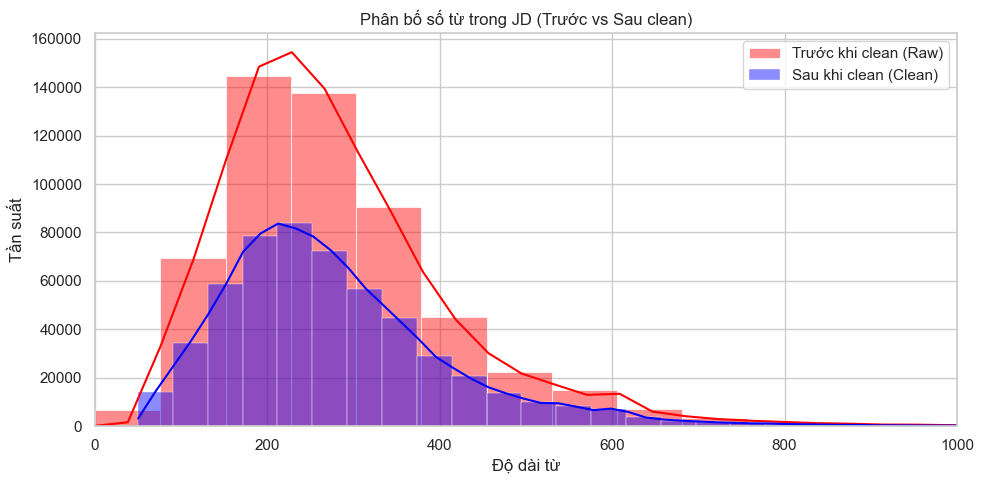

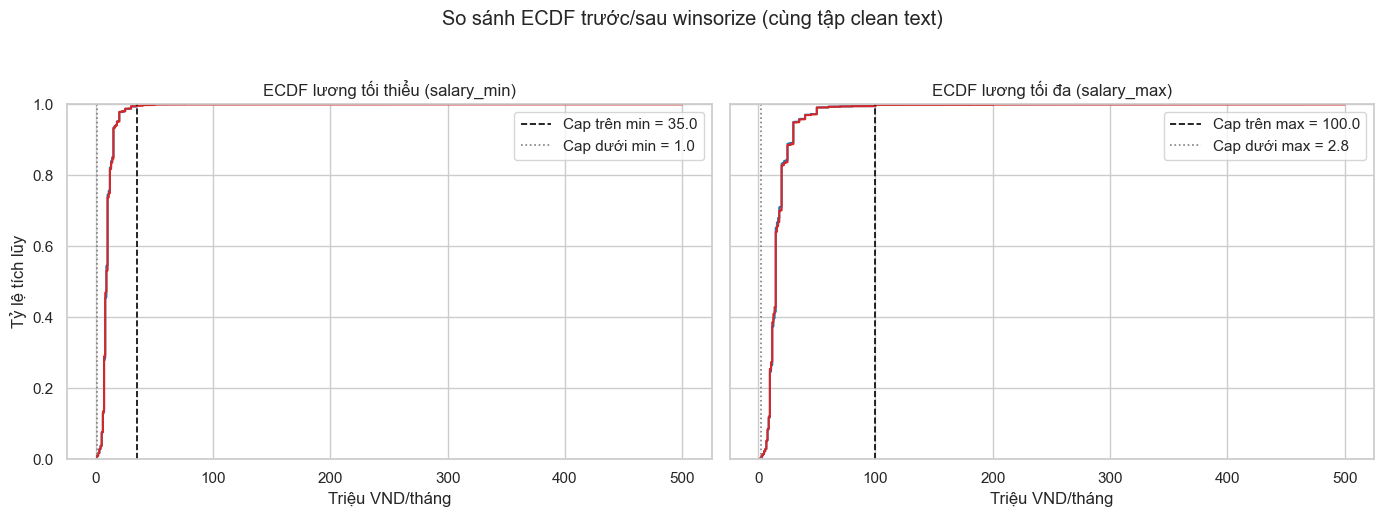

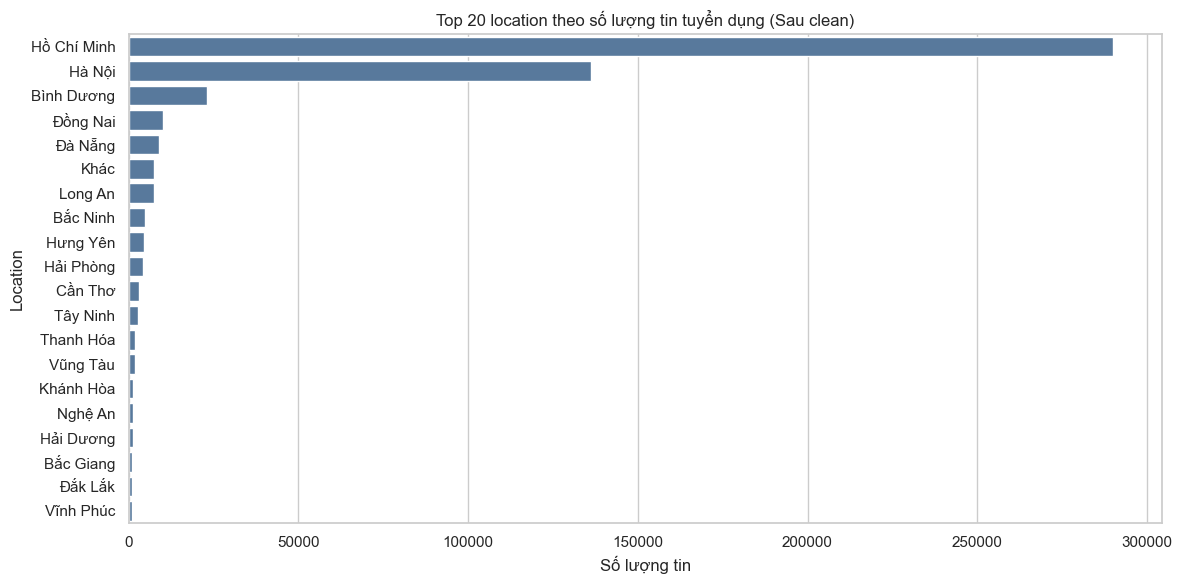

In [57]:
os.makedirs("../plots", exist_ok=True)

# 1. Tần suất số từ trước/sau clean
plt.figure(figsize=(10, 5))
sns.histplot(raw_word_counts, bins=100, color='red', alpha=0.45, label='Trước khi clean (Raw)', kde=True) # type: ignore
sns.histplot(df_clean_train['word_count'], bins=100, color='blue', alpha=0.45, label='Sau khi clean (Clean)', kde=True) # type: ignore
plt.xlim(0, 1000)
plt.title('Phân bố số từ trong JD (Trước vs Sau clean)')
plt.xlabel('Độ dài từ')
plt.ylabel('Tần suất')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/word_count_comparison.png', dpi=150)
plt.show()
plt.close()

# 2. ECDF trước/sau winsorize cho salary_min và salary_max
pre_range_df = df_clean_train[['salary_min_m_vnd_raw', 'salary_max_m_vnd_raw']].copy()
pre_range_df = pre_range_df.rename(columns={
    'salary_min_m_vnd_raw': 'salary_min_m_vnd',
    'salary_max_m_vnd_raw': 'salary_max_m_vnd'
})
pre_range_df['Giai đoạn'] = 'Trước winsorize'

post_range_df = df_clean_train[['salary_min_m_vnd', 'salary_max_m_vnd']].copy()
post_range_df['Giai đoạn'] = 'Sau winsorize'

range_data = pd.concat([pre_range_df, post_range_df], ignore_index=True)
range_data = range_data.dropna(subset=['salary_min_m_vnd', 'salary_max_m_vnd'])
range_data = range_data[(range_data['salary_min_m_vnd'] >= 0.5) & (range_data['salary_max_m_vnd'] >= 0.5)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# ECDF salary_min
sns.ecdfplot(
    data=range_data,
    x='salary_min_m_vnd',
    hue='Giai đoạn',
    palette={'Trước winsorize': '#d62728', 'Sau winsorize': '#1f77b4'},
    ax=axes[0]
)
axes[0].axvline(sal_cap_upper, color='black', linestyle='--', linewidth=1.2, label=f'Cap trên min = {sal_cap_upper:.1f}')
axes[0].axvline(sal_cap_lower, color='gray', linestyle=':', linewidth=1.2, label=f'Cap dưới min = {sal_cap_lower:.1f}')
axes[0].set_title('ECDF lương tối thiểu (salary_min)')
axes[0].set_xlabel('Triệu VND/tháng')
axes[0].set_ylabel('Tỷ lệ tích lũy')
axes[0].legend()

# ECDF salary_max
sns.ecdfplot(
    data=range_data,
    x='salary_max_m_vnd',
    hue='Giai đoạn',
    palette={'Trước winsorize': '#d62728', 'Sau winsorize': '#1f77b4'},
    ax=axes[1]
)
axes[1].axvline(sal_max_cap_upper, color='black', linestyle='--', linewidth=1.2, label=f'Cap trên max = {sal_max_cap_upper:.1f}')
axes[1].axvline(sal_max_cap_lower, color='gray', linestyle=':', linewidth=1.2, label=f'Cap dưới max = {sal_max_cap_lower:.1f}')
axes[1].set_title('ECDF lương tối đa (salary_max)')
axes[1].set_xlabel('Triệu VND/tháng')
axes[1].set_ylabel('Tỷ lệ tích lũy')
axes[1].legend()

plt.suptitle('So sánh ECDF trước/sau winsorize (cùng tập clean text)', y=1.03)
plt.tight_layout()
plt.savefig('../plots/salary_ecdf_comparison.png', dpi=150)
plt.show()
plt.close()

# 3. Số lượng location (Top 15) sau clean
plt.figure(figsize=(12, 6))
loc_counts = df_clean_train['location'].value_counts().head(20)
sns.barplot(x=loc_counts.values, y=loc_counts.index, color='#4C78A8')
plt.title('Top 20 location theo số lượng tin tuyển dụng (Sau clean)')
plt.xlabel('Số lượng tin')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('../plots/location_top20_count.png', dpi=150)
plt.show()
plt.close()


Biểu đồ lương sử dụng **ECDF trước/sau winsorize (P0.5-P99.5)** trên cùng tập đã clean text.
Vạch dọc đứt nét là ngưỡng cap trên, vạch chấm là ngưỡng cap dưới.


In [58]:
print("\n==================================================")
print("BÁO CÁO THÔNG SỐ NGOẠI LỆ & PHÂN PHỐI CHI TIẾT GIAI ĐOẠN 1")
print("==================================================")

print("\n--- THỐNG KÊ ĐỘ DÀI TỪ ---")
print(f"Độ dài từ thô: từ {raw_word_counts.min()} đến {raw_word_counts.max()} từ")
print(f"Độ dài từ sau clean: từ {df_clean_train['word_count'].min()} đến {df_clean_train['word_count'].max()} từ")

print("\n--- THỐNG KÊ MỨC LƯƠNG (Triệu VND / Tháng) ---")
print(f"Mức lương tối thiểu thô: từ {raw_salaries_min.min():.2f}M đến {raw_salaries_min.max():.2f}M VND")
print(f"Mức lương tối thiểu sau clean: từ {df_clean_train['salary_min_m_vnd'].min():.2f}M đến {df_clean_train['salary_min_m_vnd'].max():.2f}M VND")

print("\n--- THỐNG KÊ KINH NGHIỆM (Số năm) ---")
print(f"Yêu cầu kinh nghiệm tối thiểu sau clean: từ {df_clean_train['exp_min_years'].min():.1f} đến {df_clean_train['exp_min_years'].max():.1f} năm")

# Trích xuất thể hiện ngoại lệ văn bản ngắn/dài
raw_texts = df_raw_train['job_title'].fillna("") + " " + df_raw_train['job_description'].fillna("")
raw_texts_len = raw_texts.str.len()
shortest_raw_idx = raw_texts_len.idxmin()
longest_raw_idx = raw_texts_len.idxmax()

print("\nVăn bản thô kết hợp ngắn nhất (Ngoại lệ thô):")
print(f"Nội dung: {repr(raw_texts.loc[shortest_raw_idx])[:300]}")

print("\nVăn bản thô kết hợp dài nhất (Ngoại lệ thô):")
print(f"Nội dung (Trích đoạn 400 ký tự đầu):\n{raw_texts.loc[longest_raw_idx][:400]}...")

clean_texts_len = df_clean_train['text_combined'].str.len()
shortest_clean_idx = clean_texts_len.idxmin()
longest_clean_idx = clean_texts_len.idxmax()

print("\nVăn bản sạch kết hợp ngắn nhất (Không còn là ngoại lệ quá ngắn):")
print(f"Nội dung: {repr(df_clean_train.loc[shortest_clean_idx, 'text_combined'])[:300]}")

print("\nVăn bản sạch kết hợp dài nhất (Không còn là ngoại lệ quá dài):")
print(f"Nội dung (Trích đoạn 400 ký tự đầu):\n{df_clean_train.loc[longest_clean_idx, 'text_combined'][:400]}...") # type: ignore


BÁO CÁO THÔNG SỐ NGOẠI LỆ & PHÂN PHỐI CHI TIẾT GIAI ĐOẠN 1

--- THỐNG KÊ ĐỘ DÀI TỪ ---
Độ dài từ thô: từ 0 đến 7571 từ
Độ dài từ sau clean: từ 50 đến 4092 từ

--- THỐNG KÊ MỨC LƯƠNG (Triệu VND / Tháng) ---
Mức lương tối thiểu thô: từ 0.00M đến 500.00M VND
Mức lương tối thiểu sau clean: từ 1.00M đến 35.00M VND

--- THỐNG KÊ KINH NGHIỆM (Số năm) ---
Yêu cầu kinh nghiệm tối thiểu sau clean: từ 0.0 đến 15.0 năm

Văn bản thô kết hợp ngắn nhất (Ngoại lệ thô):
Nội dung: ' '

Văn bản thô kết hợp dài nhất (Ngoại lệ thô):
Nội dung (Trích đoạn 400 ký tự đầu):
[HCM] Tập Đoàn MICHELIN Tuyển Dụng Nhân Viên Kỹ Sư Cơ Khí/Cơ Sở Vật Chất/Bảo Trì Phương Pháp/Bảo Trì Điện, Kỹ Thuật Viên Đảm Bảo Chất Lượng/Phòng Thí Nghiệm, Chuyên Gia Đào Tạo, Trưởng Phòng Bảo Trì, Quản Lý Tiện Ích Full-time 2026 COMPANY INTRODUCTION Địa điểm Hồ Chí Minh At Michelin, we believe that our people are our greatest asset and we&039;re dedicated to empowering our employees to grow and...

Văn bản sạch kết hợp ngắn nhất (Không c

### Nhận xét báo cáo thông số ngoại lệ chi tiết:
- **Độ dài từ (Word Count):** dải từ được thu gọn về vùng hợp lệ, loại các tin quá ngắn/quá dài.
- **Lương:** winsorize theo train giúp giảm ảnh hưởng cực trị nhưng vẫn giữ cấu trúc phân bố chính. Trên ECDF, đường sau winsorize thể hiện thay đổi độ dốc rõ quanh ngưỡng cap.
- **Kinh nghiệm:** dải kinh nghiệm sau clean phản ánh các cấp độ từ entry đến senior, phù hợp cho bước phân cụm tiếp theo.
